# Reinforcement Learning

### Intelligentes Laden eines Elektrotaxis mithilfe von Reinforcement Learning

Bei dieser Aufgabe implementieren wir einen Ansatz des Reinforcement Learnings für das intelligente Laden eines Elektrotaxis. 
Wir nehmen an, dass das Taxi jeden Tag um 14:00 Uhr in der Garage ist und um 16:00 Uhr wieder los fährt. Während dieser Zeit entscheidet der intelligente Ladeagent alle 15 Minuten, wie viel Ladeleistung zugeführt werden soll.

Ziele:
- Minimierung der Ladekosten
- Sicherstellung, dass die Batterie genügend Energie für den Arbeitstag enthält
- Batteriemangel zu vermeiden, der zu einer hohen Strafgebühr führt

Der erste Ansatz ist ein Deep Q-Network (DQN), um die optimale Ladestrategie zu erlernen.


### 1. Imports

Für das Reinforcement Learning importieren wir einige Basic Libraries und zusätzlich die Library gymnasium. Diese Library stellt eine standardisierte Schnittstelle bereit, über die ein Agent mit einer simulierten Umgebung interagieren kann. Die Umgebung empfängt eine Aktion des Agenten und gibt anschließend den neuen Zustand, einen Reward (Belohnungswert) und die Information zurück, ob eine Epiode beendet ist. 

Allgemeine Info: Gymnasium heißt so, weil es vom Namen "Gym" kommt und bedeutet dementsprechend "Trainingshalle". Der Agent kann dort trainieren und verschiedene Aufgaben üben -> simulierte Umgebung/Environment für den Agenten

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym 
from gymnasium import spaces
from stable_baselines3 import DQN #for training the DQN agent (more later)

from stable_baselines3.common.env_checker import check_env

### 2. Environment

Um einen Agenten mithilfe von Reinforcement Learning zu trainieren, wird der Ladevorgang als Environment simuliert. Das Environment bildet die Regeln und Bedingungen des Ladevorgangs ab und umfasst folgende Annahmen:

- Batteriekapazität
- den aktuellen Ladezustand,
- die verfügbaren Ladeaktionen,
- die entstehenden Ladekosten,
- den zufälligen täglichen Energiebedarf und
- die verbleibende Zeit bis zur Abfahrt.

Der Agent interagiert mit der Umgebung, indem er Ladeaktionen auswählt. Für jede Entscheidung erhält er einen Reward (Belohnung). Dadurch lernt dieser schrittweise, welche Ladestrategie langfristig vorteilhaft ist. 

#### 2.1 Annahmen

**kWh** bezeichnet die gespeicherte Energie der Batterie, während **kW** die Ladeleistung bezeichnet.

In der Aufgabenstellung gibt es keine konkrete Batteriekapazität, sondern nur, dass diese nicht übersteigen werden darf. Wenn der Mittelwert bei $\mu = 30$ kWh liegt, bedeutet es, dass ein Taxi im Durchschnitt 30 **kWh** verbraucht. Die Standardabweichung schwankt jeweils um 5 **kWh** um den Mittelwert herum. Die Batteriekapazität solte größer sein, als der typische Tagesbedarf. Da der Tagesbedarf um die 30 kWh schwankt, denken wir uns mind. 10 bis 15 **kWh** als Sicherheitsreserve und könnten dann auf 50 **kWh** als Batteriekapazität annehmen bzw. darauf aufrunden. 

Da die Aufgabenstellung keinen konkreten Ladezustand bei Ankunft vorgibt, nehmen wir einen initialen Ladezustand von 20 kWh an. Dieser Wert beschreibt ein Taxi, das nach vorheriger Nutzung mit teilweise entladener Batterie in die Garage zurückkehrt.

Das Taxi kann zwei Stunden lang mit höchstens 22 kW geladen werden. Ohne die Kapazitätsgrenze könnten dabei maximal 44 kWh geladen werden:

$$
22\,\text{kW} \cdot 2\,\text{h} = 44\,\text{kWh}
$$

Da die Batterie zu Beginn bereits 20 kWh enthält und höchstens 50 kWh speichern kann, kann sie tatsächlich nur 30 kWh zusätzlich aufnehmen:

$$
50\,\text{kWh} - 20\,\text{kWh} = 30\,\text{kWh}
$$

Die Werte 50 kWh und 20 kWh sind Modellannahmen und können später noch verändert werden. Die Kapazität von 50 kWh liegt über dem in der Aufgabenstellung beispielhaft genannten erwarteten Energiebedarf von $\mu = 30$ kWh.

Da alle 15 Minuten eine Entscheidung getroffen wird, besteht das zweistündige Ladefenster aus acht Intervallen:

$$
\frac{2\,\text{h}}{0{,}25\,\text{h}} = 8
$$

#### 2.2 Definition des Markov Decision Process


Ein Markov Decision Process beschreibt, wie ein Agent innerhalb eines Environments Zustände beobachtet, Aktionen auswählt und dafür Rewards erhält ([GeeksforGeeks, 2026](https://www.geeksforgeeks.org/machine-learning/what-is-markov-decision-process-mdp-and-its-relevance-to-reinforcement-learning/))

Vor der Implementierung des Environments wird das Ladeproblem durch States, Actions und eine Reward-Funktion beschrieben.

- **States:** Der Zustand enthält den aktuellen Batterieladestand in kWh und den aktuellen Zeitschritt. Eine Episode umfasst acht Zeitschritte von jeweils 15 Minuten.

- **Actions:** Der Agent kann zwischen vier Ladeleistungen wählen: 0 kW, 5 kW, 11 kW und 22 kW. (zufällig für zero, low, medium, high gewählt)

- **Transition:** Der Zstand zeigt um power * 0.25, wird aber begrenzt durch die Batteriekapazität

- **Reward:** Für das Laden entstehen Kosten, die als negativer Reward berücksichtigt werden. Reicht die gespeicherte Energie bei der Abfahrt nicht für den zufällig erzeugten Energiebedarf aus, erhält der Agent eine hohe Strafe.

- **Episode:** ein simulierter Tag von 14:00 bis 16:00 Uhr.

- **Terminal condition:** nach 8 Ladeeentscheidungen

Nach jeder Aktion wird der Batterieladestand aktualisiert. Nach acht Entscheidungen endet die Episode und der Energiebedarf für den Arbeitstag wird aus einer Normalverteilung erzeugt. 


#### 2.3 Implementierung des Environments

Jetzt werden die definierten Annahmen in einem eigenen Gymnasium-Environment umgesetzt. Die Batteriekapazität beträgt 50 kWh und der Batterieladestand ist bei Ankunft um 14:00 Uhr bei 20 kWh. Eine Episode umfasst 8 Ladeentscheidungen.

Die Ladeleistung kann von 0, 5, 11 und 22 kW variieren. Nach jeder Aktion wird innerhalb von 15 Minuten die geladene Energie berechnet und zum Batterieladestand addiert. Dabei wird sichergestellt, dass die maximale Batteriekapazität nicht überschritten wird. 

In [2]:
#defining the custom environment for the taxi charging problem, inheriting from gym.Env
class TaxiChargingEnv(gym.Env):
    def __init__(self):

        super().__init__()

        self.capacity = 50.0 #maximum battery capacity in kWh
        self.initial_soc = 20.0 #battery level when arriving home/garage

        self.max_steps = 8 #number of charging decision (2 hours / 15 minutes = 8 intervals)
        self.current_step = 0 #counter for current time
        self.power_levels = [0, 5, 11, 22] #defining charging actions (zero, low, medium, high)

        self.interval_hours = 0.25 #one charging interval is 15 minutes = 0.25 hours

        self.demand_mean = 30 #average energy demand after leaving the garage
        self.demand_std = 5 #standard deviation of the energy demand

        self.shortage_penalty = 1000 #high penalty for not having enough energy

        #time-dependent cost factor alpha_t, like described in the assignment
        #later time steps are slightly more expensive in this simplified setup
        self.alpha_t = np.array(
            [0.006, 0.007, 0.008, 0.010, 0.012, 0.014, 0.017, 0.020],
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(len(self.power_levels)) #4 possible actions

        # ---- State ---- 
        self.observation_space = spaces.Box(
            low=np.array([0, 0], dtype=np.float32), #kleinste erluabter Wert für Ladestand, Zeitschritt
            high=np.array([50, 8], dtype=np.float32), #größte erluabter Wert für Ladestand, Zeitschritt
            dtype=np.float32
        )

    def reset(self, seed=None, options=None): #initialize a new charging epiode (function is called at the beginning of each episode)

        super().reset(seed=seed) #

        self.current_step = 0 #starting at 2 pm
        self.soc = self.initial_soc #starting from battery level of 20 kwh (asumption)
        self.total_cost = 0.0 #tracking total charging cost over the episode

        obs = np.array(
            [self.soc, self.current_step],
            dtype=np.float32
        ) #returning the initial state of the environment (battery level and time step) to the agent

        return obs, {} #returning this

    def step(self, action): #this function is called at each time step when the agent takes an action(choosing a charging power level)

        power = self.power_levels[int(action)] #mapping the action to the corresponding charging power level
        energy_added = power * self.interval_hours #calculating the energy added to the battery (power in kW * time in hours (15minutes = 0.25 hours))

        previous_soc = self.soc #saving old battery level to calculate actual added energy

        self.soc = min(
            self.capacity,
            self.soc + energy_added
        ) #updating the state of charge (soc) of the battery, ensuring it does not exceed the maximum capacity

        actual_energy_added = self.soc - previous_soc #actual energy added after respecting battery capacity

        alpha = self.alpha_t[self.current_step] #time-dependent cost factor for charging

        #charging cost level, like described in the assignment as a first step 
        charging_cost = alpha * np.exp(power)

        self.total_cost += charging_cost #adding current charging cost to total charging cost

        reward = -charging_cost #reward is negative cost, so the agent is incentivized to minimize the charging cost

        self.current_step += 1

        terminated = False #assuming the episode is not terminated until we reach the end of the time steps

        info = {
            "power": power,
            "requested_energy": energy_added,
            "energy_added": actual_energy_added,
            "unused_energy": energy_added - actual_energy_added,
            "charging_cost": charging_cost,
            "total_cost": self.total_cost,
            "alpha_t": alpha,
            "soc": self.soc,
        }#saving additional information for evaluation and debugging

        if self.current_step >= self.max_steps: #if we have reached the maximum number of time steps (end of the episode)

            demand = self.np_random.normal( # simulating the energy demand for the next day using a normal distribution (assignment says)
                loc=self.demand_mean, #average energy demand for the next day
                scale=self.demand_std #standard deviation of the energy demand
            )

            demand = max(0.0, float(demand)) #making sure demand cannot be negative

            shortage = max(0.0, demand - self.soc) #calculating missing energy if demand is higher than final battery level

            if self.soc < demand: #checking if the state of charge is less than the demand for the next day, which would indicate that the agent has not charged enough)
                reward -= self.shortage_penalty * shortage #penalty for not meeting the demand, scaled by missing kWh
            else:
                reward += 100 #reward for having enough energy at departure

            info.update({
                "demand": demand,
                "shortage": shortage,
                "success": shortage == 0.0,
                "final_soc": self.soc
            }) #saving final episode information

            terminated = True #ending the episode after 8 time steps :)

        obs = np.array( #new state of the environment
            [self.soc, self.current_step],
            dtype=np.float32
        )

        return obs, reward, terminated, False, info #returnnnnnn

Der wichtigste Teil in der Environment, ist die Kostenfunktion, alles andere wurden in der Annahme erklärt. In der Aufgabenstellung wird folgende Kostenfunktion als Beispiel genannt:

$$
\text{charging cost}(t,p) = \sum_{t \in T} \alpha_t e^p
$$,

wobei $\alpha_t$ die Zeit darstellt (Tag) und $p$ die Ladeaktion.
Im ersten Schritt haben wir sie so angenommen und demensprechend in der Environment umgesetzt.

In [3]:
envTest = TaxiChargingEnv() #creating instance of the environment
check_env(envTest) #check check
print("Environment check passed!")

Environment check passed!


#### 2.4 Environment manuell testen

Bevor man jetzt einen Agenten trainiert, testen wir das Environment vorher, um Fehler zu vermeiden. Dazu prüfen wir mit einer Aktion, ob Ladestand und Reward korrekt verändert werden.

In [4]:
obs, info = envTest.reset()
print("Startzustand:", obs) 

Startzustand: [20.  0.]


In [5]:
test_results_TESTING = []

terminated = False
truncated = False

while not terminated and not truncated:
    action = 3 # action 3 corresponds to 11 kW

    old_soc = obs[0]
    old_step = obs[1]

    obs, reward, terminated, truncated, info = envTest.step(action)

    test_results_TESTING.append({
        "Zeitschritt": int(old_step),
        "Ladestand vorher": old_soc,
        "Aktion": action,
        "Ladeleistung_kW": info["power"],
        "Alpha_t": info["alpha_t"],
        "Ladekosten": info["charging_cost"],
        "Ladestand nachher": obs[0],
        "Reward": reward,
        "Demand": info.get("demand", np.nan),
        "Shortage": info.get("shortage", np.nan),
        "Success": info.get("success", np.nan),
        "Beendet": terminated
    })

In [6]:
test_df = pd.DataFrame(test_results_TESTING)
test_df

,Zeitschritt,Ladestand vorher,Aktion,Ladeleistung_kW,Alpha_t,Ladekosten,Ladestand nachher,Reward,Demand,Shortage,Success,Beendet
0,0,20.0,3,22,0.006,2.150948e+07,25.5,-2.150948e+07,NaN,NaN,NaN,False
1,1,25.5,3,22,0.007,2.509439e+07,31.0,-2.509439e+07,NaN,NaN,NaN,False
2,2,31.0,3,22,0.008,2.867930e+07,36.5,-2.867930e+07,NaN,NaN,NaN,False
3,3,36.5,3,22,0.010,3.584913e+07,42.0,-3.584913e+07,NaN,NaN,NaN,False
4,4,42.0,3,22,0.012,4.301895e+07,47.5,-4.301895e+07,NaN,NaN,NaN,False
5,5,47.5,3,22,0.014,5.018878e+07,50.0,-5.018878e+07,NaN,NaN,NaN,False
6,6,50.0,3,22,0.017,6.094352e+07,50.0,-6.094352e+07,NaN,NaN,NaN,False
7,7,50.0,3,22,0.020,7.169826e+07,50.0,-7.169816e+07,29.339476,0.0,True,True


### 4.Deep-Q-Network-Agent erstellen

Deep-Q-Learning ist eine Methode, die Deep Learning nutzt, um Maschinen dabei zu helfen, Entscheidungen in komplexen Situationen zu treffen, wobei sie in Umgebungen nützlich ist, wo die Anzahl der möglichen Situationen (Zustände) groß ist.
Es handelt sich um eine modellfreie Methode, die eine optimale Strategie erlernt, indem sie die Q-Wert-Funktion nutzt, die angibt, wie vorteilhaft es ist, in einer bestimmten Situation eine bestimmte Aktion auszuführen.

Ziel: einen Plan zu finden, der im Laufe der Zeit die höchste Gesamtbelohnung liefert ([GeeksforGeeks, 2026](https://www.geeksforgeeks.org/deep-learning/deep-q-learning/))

Nachdem wir das Environment definiert und manuell getestet haben, wird ein Deep-Q-Network (DQN)-Agent erstellt. Der Agent interagiert während des Trainings wiederholt mit der simulierten Ladeumgebung (hier vordefinierte Environment). Dabei beobachtet er/sie den aktuellen Ladestand und den Zeitschritt und wählt anschließend eine der verfügbaren Ladeleistungen aus. 

Für jede Aktion erhält der Agent einen Belohnungswert. Dieser berücksichtigt die Ladekosten sowie eine Belohnung bei ausreichender Energie bzw. eine hohe Strafe bei einem Energiemangel zum Zeitpunkt der Abfahrt. Durch die wiederholte Interaktion lernt der Agent, welche Ladeentscheidung in einem bestimmten Zustand langfristig den höchsten kumulierten Belohnungswert erzielt.

Das Training umfasst 50.000 Zeitschritte. Da eine Episode aus acht Ladeentscheidungen besteht, entspricht dies ungefähr:

$$
\frac{50.000}{8}=6.250
$$

simulierten Ladetagen bzw. Episoden.


In [7]:
env = TaxiChargingEnv() #creating instance of the environment for training the agent
model = DQN( #hyperparameters for training the DQN agent, can be tuned later if the results are not good
    "MlpPolicy", #simple neural network policy for the agent
    env, 
    learning_rate=0.001, 
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [8]:
model.learn(
    total_timesteps=50000
)

-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 8         |
|    ep_rew_mean      | -8.25e+07 |
|    exploration_rate | 0.994     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 12794     |
|    time_elapsed     | 0         |
|    total_timesteps  | 32        |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 8         |
|    ep_rew_mean      | -7.17e+07 |
|    exploration_rate | 0.988     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 17213     |
|    time_elapsed     | 0         |
|    total_timesteps  | 64        |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 8         |
|    ep_rew_mean      | -8.07e+07 |
|    exploration_rate | 0.982     |
| time/               |     

In [9]:
model.save("taxi_charging_dqn") #saving modelllll

#### Evaluation

Beschreibung folgt...

In [10]:
# Evaluation of the trained DQN agent
n_episodes = 1000
rewards = []
successes = 0

for _ in range(n_episodes):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    info = {}

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        total_reward += reward

    rewards.append(total_reward)

    if info["success"]:
        successes += 1

print(f"Erfolgsquote: {successes / n_episodes * 100:.2f}%")
print(f"Durchschnittlicher Reward: {np.mean(rewards):.2f}")


Erfolgsquote: 2.30%
Durchschnittlicher Reward: -9772.38


In [11]:
action_counts = np.zeros(len(env.power_levels))

for _ in range(1000):
    obs, _ = env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action_counts[int(action)] += 1
        obs, _, done, _, _ = env.step(action)

print(dict(zip(env.power_levels, action_counts)))

{0: np.float64(8000.0), 5: np.float64(0.0), 11: np.float64(0.0), 22: np.float64(0.0)}


In [12]:
episode_results = []

obs, _ = env.reset()
done = False

while not done:
    old_soc = obs[0]
    old_step = obs[1]

    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)

    episode_results.append({
        "Zeitschritt": int(old_step),
        "Ladestand vorher": old_soc,
        "Aktion": int(action),
        "Ladeleistung_kW": info["power"],
        "Ladekosten": info["charging_cost"],
        "Ladestand nachher": obs[0],
        "Reward": reward,
        "Demand": info.get("demand", np.nan),
        "Shortage": info.get("shortage", np.nan),
        "Success": info.get("success", np.nan)
    })

episode_df = pd.DataFrame(episode_results)
episode_df

,Zeitschritt,Ladestand vorher,Aktion,Ladeleistung_kW,Ladekosten,Ladestand nachher,Reward,Demand,Shortage,Success
0,0,20.0,0,0,0.006,20.0,-0.006000,NaN,NaN,NaN
1,1,20.0,0,0,0.007,20.0,-0.007000,NaN,NaN,NaN
2,2,20.0,0,0,0.008,20.0,-0.008000,NaN,NaN,NaN
3,3,20.0,0,0,0.010,20.0,-0.010000,NaN,NaN,NaN
4,4,20.0,0,0,0.012,20.0,-0.012000,NaN,NaN,NaN
5,5,20.0,0,0,0.014,20.0,-0.014000,NaN,NaN,NaN
6,6,20.0,0,0,0.017,20.0,-0.017000,NaN,NaN,NaN
7,7,20.0,0,0,0.020,20.0,-3351.660731,23.351641,3.351641,False


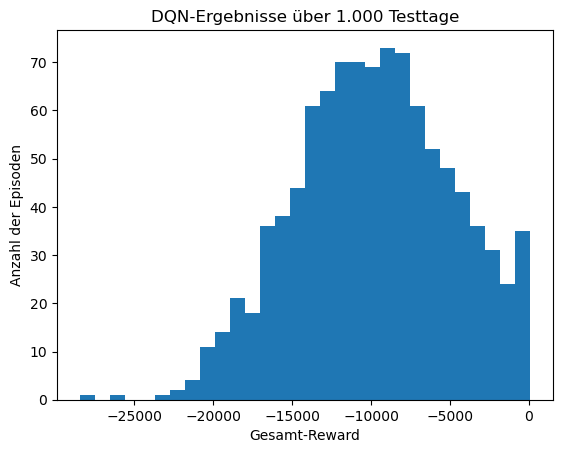

In [13]:
plt.hist(rewards, bins=30)
plt.xlabel("Gesamt-Reward")
plt.ylabel("Anzahl der Episoden")
plt.title("DQN-Ergebnisse über 1.000 Testtage")
plt.show()


In [14]:
print(dict(zip(env.power_levels, action_counts)))

{0: np.float64(8000.0), 5: np.float64(0.0), 11: np.float64(0.0), 22: np.float64(0.0)}


Durch die aktuelle Kostenfunktion lädt der Agent so gut wie nie. Der Agent sieht also:

Wenn ich lade, bekomme ich sofort große negative Rewards. Wenn ich nicht lade, bekomme ich fast keine direkten Kosten. Später weiter machen bzw dokumentieren. 